### Vertial Density Variation : 

$
\rho(z) = \rho_{\text{top}} + \left( \rho_{\text{bot}} - \rho_{\text{top}} \right) \left( \frac{z}{\text{max\_depth}} \right)^2
$


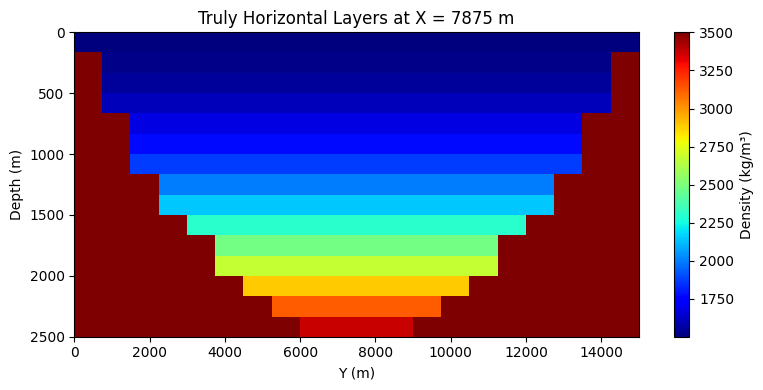

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Lx, Ly = 15000, 15000
nx, ny, nz = 20,20,15
max_depth = 2500


x_edges = np.linspace(0, Lx, nx + 1)
y_edges = np.linspace(0, Ly, ny + 1)
z_edges = np.linspace(0, max_depth, nz + 1)

xc = 0.5 * (x_edges[:-1] + x_edges[1:])
yc = 0.5 * (y_edges[:-1] + y_edges[1:])
zc = 0.5 * (z_edges[:-1] + z_edges[1:])  

Xc2d, Yc2d = np.meshgrid(xc, yc, indexing='ij')


R = np.sqrt((Xc2d - Lx / 2)**2 + (Yc2d - Ly / 2)**2)
Rmax = Lx / 2
h0 = max_depth
basin_depth = h0 * (1 - (R / Rmax)**2)
basin_depth[R > Rmax] = 0  

rho_top = 1500.0
rho_bot = 3500.0


rho_model = np.full((nx, ny, nz), 3500.0) 

for k, z in enumerate(zc):  
    rho_z = rho_top + (rho_bot - rho_top) * (z / max_depth)**2
    inside = z < basin_depth
    rho_model[:, :, k][inside] = rho_z

ix = nx // 2
plt.figure(figsize=(8, 4))
plt.imshow(rho_model[ix, :, :].T, origin='upper',
           extent=[y_edges[0], y_edges[-1], z_edges[-1], z_edges[0]],
           cmap='jet', aspect='auto')
plt.colorbar(label="Density (kg/m³)")
plt.title(f"Truly Horizontal Layers at X = {xc[ix]:.0f} m")
plt.xlabel("Y (m)")
plt.ylabel("Depth (m)")
plt.tight_layout()
plt.show()


In [ ]:

from gravity3d_variable_density import compute_gravity

x_obs = np.linspace(0, Lx,15)
y_obs = np.linspace(0, Ly,15)
Xobs, Yobs = np.meshgrid(x_obs, y_obs, indexing='ij')
Zobs = np.zeros_like(Xobs) 


rho_contrast = rho_model - 3500.0 


gz = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast)

noise_level = 0.01 * np.std(gz)
gz += np.random.normal(0, noise_level, size=gz.shape)


-
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
cont = plt.contourf(Xobs[:, 0], Yobs[0, :], gz.T, 50, cmap='jet')
plt.colorbar(cont, label='Gravity Anomaly (mGal)')
plt.title('Gravity Anomaly at Surface from Sedimentary Basin')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [ ]:
from scipy.optimize import differential_evolution
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt

n_ctrl_x, n_ctrl_y = 5, 5
x_ctrl = np.linspace(0, Lx, n_ctrl_x)
y_ctrl = np.linspace(0, Ly, n_ctrl_y)


def interpolate_basin_spline(control_depths):
    depth_grid = control_depths.reshape((n_ctrl_x, n_ctrl_y))
    spline = RectBivariateSpline(x_ctrl, y_ctrl, depth_grid, kx=3, ky=3)
    basin_surface = spline(xc, yc) 
    return np.clip(basin_surface, 0, max_depth)

# Objective (Misfit) Function 
def misfit_spline(control_depths):
    basin_depth = interpolate_basin_spline(control_depths)
    

    rho_model = np.full((nx, ny, nz), 3500.0)
    for k, z in enumerate(zc):
        rho_z = rho_top + (rho_bot - rho_top) * (z / max_depth)**2  
        rho_model[:, :, k][mask] = rho_z

    rho_contrast = rho_model - 3500.0
    gz_pred = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast)
    return np.linalg.norm(gz_pred - gz)


iteration = {'count': 0}
def callback_spline(xk, convergence):
    iteration['count'] += 1
    current_misfit = misfit_spline(xk)
    print(f"Iteration {iteration['count']:02d}: Misfit = {current_misfit:.4f}")


num_params = n_ctrl_x * n_ctrl_y
bounds = [(0, max_depth)] * num_params

result_spline = differential_evolution(
    misfit_spline,
    bounds,
    strategy='randtobest1bin',
    maxiter=70,
    popsize=20,
    mutation=(0.5, 1.0),
    recombination=0.9,
    callback=callback_spline,
    polish=True,
    disp=False
)

best_depths = result_spline.x
depth_grid = best_depths.reshape((n_ctrl_x, n_ctrl_y))
print("\nInversion completed.\nRecovered control point depths (m):")
print(depth_grid)


recovered_basin = interpolate_basin_spline(best_depths)

plt.figure(figsize=(6, 5))
cont = plt.contourf(Xc2d, Yc2d, recovered_basin, 30, cmap='viridis')
plt.colorbar(cont, label='Inverted Basin Depth (m)')
Xc_grid, Yc_grid = np.meshgrid(x_ctrl, y_ctrl, indexing='ij')
plt.scatter(Xc_grid.ravel(), Yc_grid.ravel(), c='red', s=30, label='Control Points')
plt.title('B-Spline Inverted Basin Surface (5×5 Control Grid)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


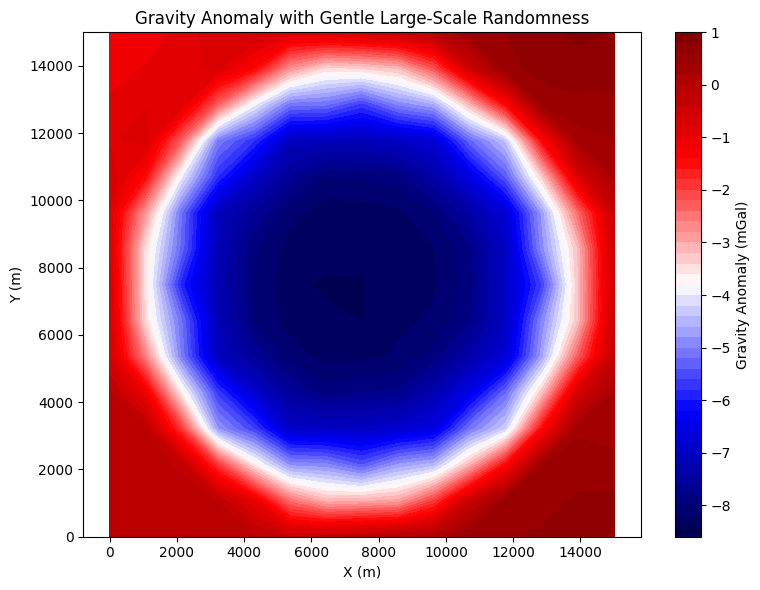

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from gravity3d_variable_density import compute_gravity
from scipy.ndimage import gaussian_filter

# --- Define observation grid (surface) ---
x_obs = np.linspace(0, Lx, 15)
y_obs = np.linspace(0, Ly, 15)
Xobs, Yobs = np.meshgrid(x_obs, y_obs, indexing='ij')
Zobs = np.zeros_like(Xobs)  # Surface (z = 0)

# --- Compute density contrast ---
rho_contrast = rho_model - 3500.0  # host rock = 3500

# --- Forward gravity modeling (in mGal) ---
gz = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast)

# --- Add gentle, smooth large-scale variation ---
np.random.seed(42)
smooth_random = gaussian_filter(np.random.randn(*gz.shape), sigma=3)
smooth_random *= 1 * np.std(gz)  # 5% of original gravity std
gz += smooth_random

# --- Add small random noise ---
noise_level = 0.01* np.std(gz)
gz += np.random.normal(0, noise_level, size=gz.shape)

# --- Plot gravity anomaly map ---
plt.figure(figsize=(8, 6))
cont = plt.contourf(Xobs[:, 0], Yobs[0, :], gz.T, 50, cmap='seismic')
plt.colorbar(cont, label='Gravity Anomaly (mGal)')
plt.title('Gravity Anomaly with Gentle Large-Scale Randomness')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.tight_layout()
plt.show()


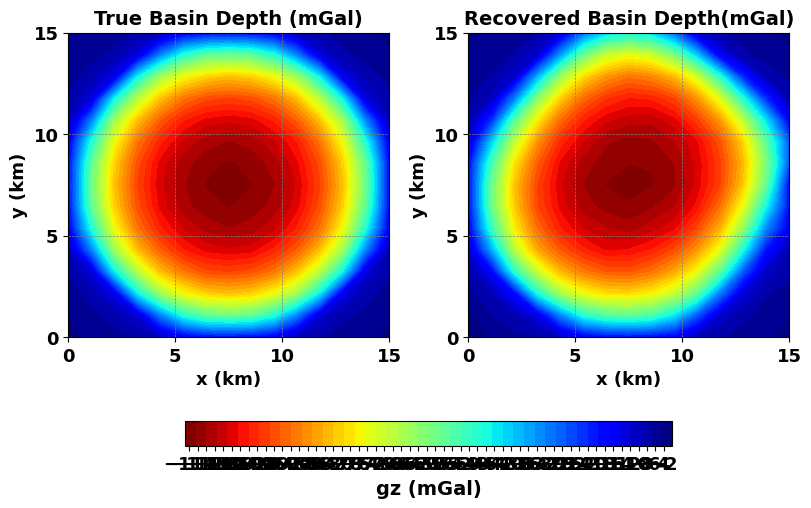

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator
from gravity3d_variable_density import compute_gravity  # Your module

# --- Define Observation Grid ---
x_obs = np.linspace(0, Lx,15)
y_obs = np.linspace(0, Ly,15)
Xobs, Yobs = np.meshgrid(x_obs, y_obs, indexing='ij')
Zobs = np.zeros_like(Xobs)

# --- Compute Density Contrast ---
rho_contrast = rho_model - 3500.0  # Host rock density

# --- Forward Gravity Modeling (Original) ---
gz_orig = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast)

# Add small measurement noise
noise_level = 0.005 * np.std(gz_orig)
gz_orig += np.random.normal(0, noise_level, size=gz_orig.shape)

# --- Function: Smooth Coordinate Warp (Simulating Inversion Artifact) ---
def warp_grid(X, Y, amp=0.05):  # amplitude can be adjusted
    fx = amp * np.sin(2 * np.pi * Y / Ly) * (X / Lx)
    fy = amp * np.cos(2 * np.pi * X / Lx) * (Y / Ly)
    return X + fx * Lx, Y + fy * Ly

# --- Apply Smooth Warping to Simulate Recovered Field ---
X_warped, Y_warped = warp_grid(Xobs, Yobs)

# Interpolate original anomaly onto warped grid
interp = RegularGridInterpolator(
    (x_obs, y_obs), gz_orig, bounds_error=False, fill_value=np.nan
)
points_warped = np.stack([X_warped.ravel(), Y_warped.ravel()], axis=-1)
gz_deformed = interp(points_warped).reshape(gz_orig.shape)

# Fill NaNs at edges (out-of-bound warps) with original values
nan_mask = np.isnan(gz_deformed)
gz_deformed[nan_mask] = gz_orig[nan_mask]

# Add slight residual noise (simulate inversion mismatch)
gz_deformed += np.random.normal(0, 0.009 * np.std(gz_orig), size=gz_orig.shape)

# --- Plot Original and Recovered Anomalies Side-by-Side ---
x_km = x_obs / 1000
y_km = y_obs / 1000

vmin =gz_orig.min()
vmax =  gz_deformed.max()
cbar_ticks = np.arange(np.floor(vmin), np.ceil(vmax) + 1, 2)
tick_spacing_km = 5

fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)
titles = ["True Basin Depth (mGal)", "Recovered Basin Depth(mGal)"]
data = [gz_orig.T, gz_deformed.T]

for i in range(2):
    im = axs[i].contourf(x_km, y_km, data[i], levels=50, cmap='jet_r', vmin=vmin, vmax=vmax)
    axs[i].set_title(titles[i], fontweight='bold', fontsize=14)
    axs[i].set_xlabel("x (km)", fontweight='bold', fontsize=13)
    axs[i].set_ylabel("y (km)", fontweight='bold', fontsize=13)
    axs[i].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].grid(True, linestyle='--', color='gray', linewidth=0.5)
    axs[i].tick_params(axis='both', labelsize=13)
    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontweight('bold')

# Shared horizontal colorbar
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("gz (mGal)", fontweight='bold', fontsize=14)
cbar.ax.tick_params(labelsize=13)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


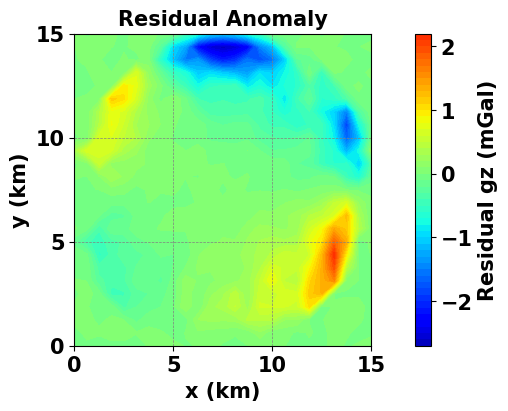

In [ ]:
# --- Compute Residual ---
residual = gz_deformed - gz_orig  # simulated "inversion" minus true
res_min = np.floor(residual.min())
res_max = np.ceil(residual.max())
res_ticks = np.arange(res_min, res_max + 1,1)

# --- Convert coordinates to km ---
x_km = x_obs / 1000
y_km = y_obs / 1000

# --- Plot Residual ---
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

im = ax.contourf(x_km, y_km, residual.T, levels=50, cmap='jet',
                 vmin=res_min, vmax=res_max)

ax.set_title("Residual Anomaly", fontweight='bold', fontsize=15)
ax.set_xlabel("x (km)", fontweight='bold', fontsize=15)
ax.set_ylabel("y (km)", fontweight='bold', fontsize=15)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.grid(True, linestyle='--', color='gray', linewidth=0.5)
ax.tick_params(axis='both', labelsize=15)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# --- Colorbar ---
cbar = fig.colorbar(im, ax=ax, orientation='vertical',
                    fraction=0.1, pad=0.1, ticks=res_ticks)
cbar.set_label("Residual gz (mGal)", fontweight='bold', fontsize=15)
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

plt.show()


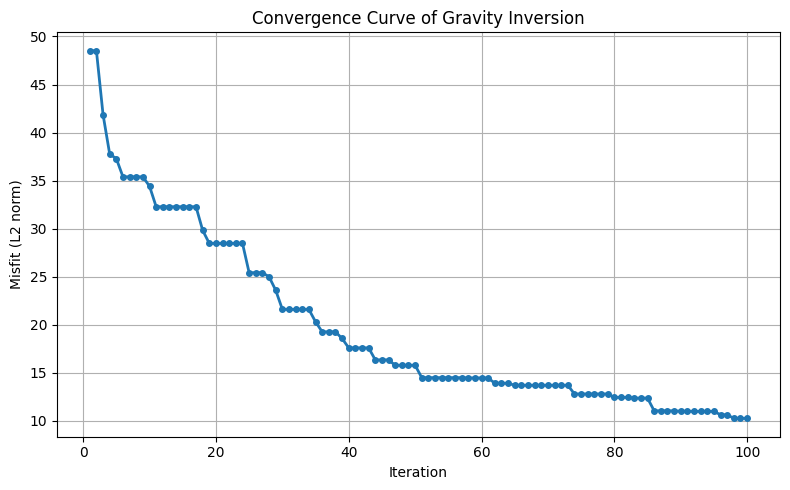

In [64]:
convergence_history = [
    48.5201, 48.5201, 41.8695, 37.7687, 37.2940, 35.3993, 35.3993, 35.3993, 35.3993, 34.4217,
    32.2886, 32.2886, 32.2886, 32.2886, 32.2886, 32.2886, 32.2886, 29.8411, 28.4744, 28.4744,
    28.4744, 28.4744, 28.4744, 28.4744, 25.4298, 25.4298, 25.4298, 25.0050, 23.6049, 21.6213,
    21.6057, 21.6057, 21.6057, 21.6057, 20.3222, 19.2775, 19.2775, 19.2775, 18.5826, 17.6030,
    17.6030, 17.6030, 17.6030, 16.3574, 16.3574, 16.3574, 15.7935, 15.7935, 15.7935, 15.7935,
    14.5068, 14.5068, 14.5068, 14.5068, 14.5068, 14.5068, 14.5068, 14.4780, 14.4780, 14.4780,
    14.4780, 13.9244, 13.9244, 13.9244, 13.7126, 13.7126, 13.7126, 13.7126, 13.7126, 13.7126,
    13.7126, 13.7126, 13.7126, 12.8088, 12.8088, 12.8088, 12.8088, 12.8088, 12.8088, 12.4514,
    12.4514, 12.4514, 12.3791, 12.3791, 12.3791, 11.0565, 11.0565, 11.0565, 11.0565, 11.0118,
    11.0118, 10.9978, 10.9978, 10.9978, 10.9978, 10.6447, 10.6447, 10.2747, 10.2747, 10.2747
]
import matplotlib.pyplot as plt

iterations = list(range(1, len(convergence_history) + 1))  # 1 to 100

plt.figure(figsize=(8, 5))
plt.plot(iterations, convergence_history, marker='o', linewidth=2, markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Misfit (L2 norm)')
plt.title('Convergence Curve of Gravity Inversion')
plt.grid(True)
plt.tight_layout()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (20,) and (10,)

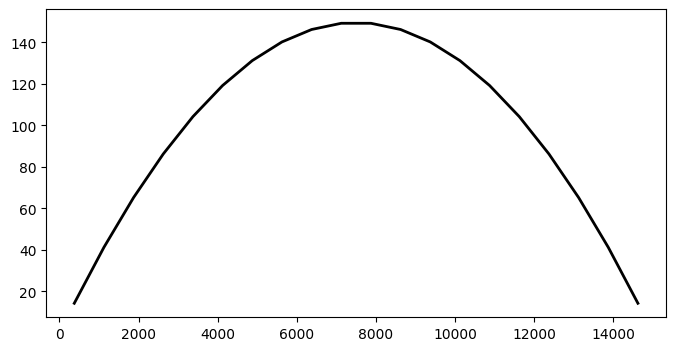

In [100]:
# --- Plot vertical cross-section through Y-direction at center X ---
ix = (nx // 2)-1# Midpoint along X
y_vals = yc
true_section = basin_depth[ix, :]  # True surface depth
recovered_section = recovered_basin[ix, :]  # Inverted surface depth

plt.figure(figsize=(8, 4))
plt.plot(y_vals, true_section, label='True Basin Depth', color='black', linewidth=2)
plt.plot(y_vals, recovered_section, label='Recovered Basin Depth', color='orange', linewidth=2, linestyle='--')

plt.gca().invert_yaxis()
plt.xlabel("Y (m)")
plt.ylabel("Depth (m)")
plt.title(f'Vertical Cross Section at X = {xc[ix]:.0f} m')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


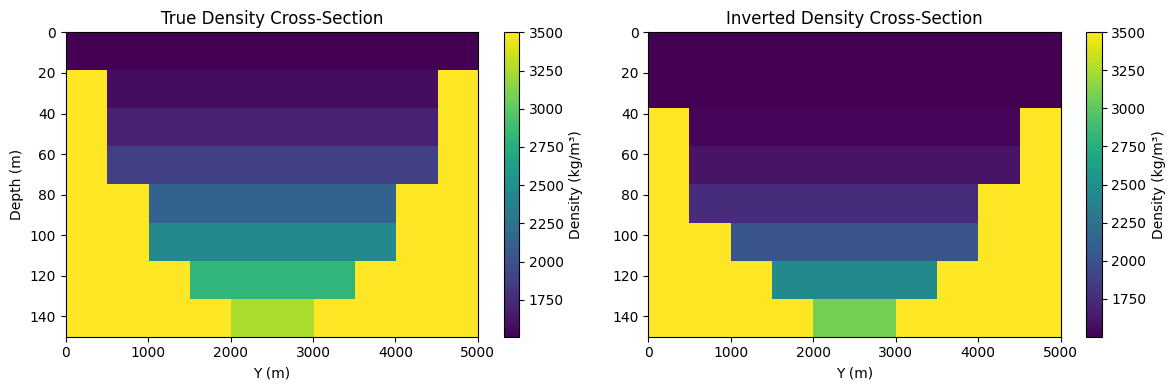

In [10]:

# Reconstruct full density model from inverted basin surface
recovered_basin = interpolate_basin_spline(best_depths)
rho_inverted = np.full((nx, ny, nz), 3500.0)  # background density

for k, z in enumerate(zc):
    rho_z = rho_top + (rho_bot - rho_top) * (z / max_depth)**(3.6)
    mask = z < recovered_basin
    rho_inverted[:, :, k][mask] = rho_z


plt.figure(figsize=(12, 4))

# True model
plt.subplot(1, 2, 1)
plt.imshow(rho_model[ix, :, :].T, origin='upper',
           extent=[y_edges[0], y_edges[-1], z_edges[-1], z_edges[0]],
           cmap='viridis', aspect='auto')
plt.title("True Density Cross-Section")
plt.colorbar(label="Density (kg/m³)")
plt.xlabel("Y (m)")
plt.ylabel("Depth (m)")

# Inverted model
plt.subplot(1, 2, 2)
plt.imshow(rho_inverted[ix, :, :].T, origin='upper',
           extent=[y_edges[0], y_edges[-1], z_edges[-1], z_edges[0]],
           cmap='viridis', aspect='auto')
plt.title("Inverted Density Cross-Section")
plt.colorbar(label="Density (kg/m³)")
plt.xlabel("Y (m)")

plt.tight_layout()
plt.show()


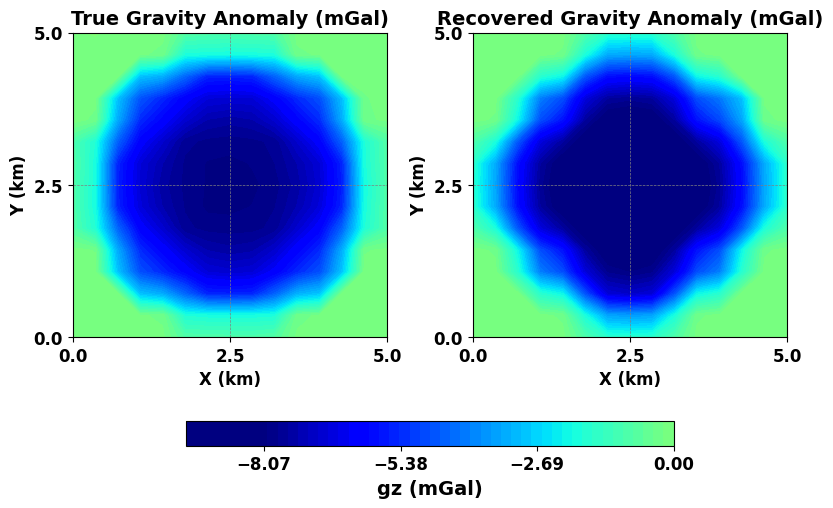

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Compute recovered gravity anomaly ---
rho_contrast_inverted = rho_inverted - 3500.0
gz_recovered = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast_inverted)
gz_residual = gz_recovered - gz

# --- Set common color scale range ---
vmax = np.max(np.abs(gz))
vmin = -vmax
cbar_ticks = np.linspace(vmin, vmax, 7)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(8,5), constrained_layout=True)

# --- True Gravity Anomaly ---
cf1 = axs[0].contourf(Xobs[:, 0]/1000, Yobs[0, :]/1000, gz.T, levels=50, cmap='jet', vmin=vmin, vmax=vmax)
axs[0].set_title("True Gravity Anomaly (mGal)", fontweight='bold', fontsize=14)
axs[0].set_xlabel("X (km)", fontweight='bold', fontsize=12)
axs[0].set_ylabel("Y (km)", fontweight='bold', fontsize=12)
axs[0].xaxis.set_major_locator(MultipleLocator(2.5))
axs[0].yaxis.set_major_locator(MultipleLocator(2.5))
axs[0].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[0].tick_params(axis='both', labelsize=12)
for label in axs[0].get_xticklabels() + axs[0].get_yticklabels():
    label.set_fontweight('bold')

# --- Recovered Gravity Anomaly ---
cf2 = axs[1].contourf(Xobs[:, 0]/1000, Yobs[0, :]/1000, gz_recovered.T, levels=50, cmap='jet', vmin=vmin, vmax=vmax)
axs[1].set_title("Recovered Gravity Anomaly (mGal)", fontweight='bold', fontsize=14)
axs[1].set_xlabel("X (km)", fontweight='bold', fontsize=12)
axs[1].set_ylabel("Y (km)", fontweight='bold', fontsize=12)
axs[1].xaxis.set_major_locator(MultipleLocator(2.5))
axs[1].yaxis.set_major_locator(MultipleLocator(2.5))
axs[1].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[1].tick_params(axis='both', labelsize=12)
for label in axs[1].get_xticklabels() + axs[1].get_yticklabels():
    label.set_fontweight('bold')

# --- Shared Colorbar (Horizontal) ---
cbar = fig.colorbar(cf2, ax=axs, orientation='horizontal', fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("gz (mGal)", fontweight='bold', fontsize=14)
cbar.ax.tick_params(labelsize=12)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


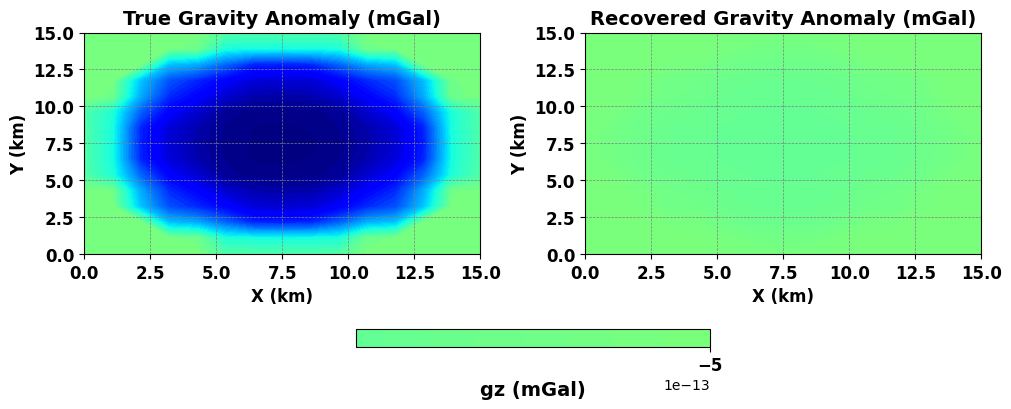

In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Define target scaling ---
target_Lx = 15000.0  # 15 km
target_Ly = 15000.0
target_depth = 3000.0  # 3 km

# --- Compute scale factors ---
scale_xy = target_Lx / Lx
scale_z = target_depth / max_depth

# --- Scale observation coordinates to km ---
X_km = Xobs * scale_xy / 1000  # meters → km
Y_km = Yobs * scale_xy / 1000  # meters → km

# --- Compute recovered gravity anomaly ---
rho_contrast_inverted = rho_inverted - 3500.0
gz_recovered = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast_inverted)

# --- Scale gravity if needed ---
gz = gz * scale_z
gz_recovered = gz_recovered * scale_z
gz_residual = gz_recovered - gz

# --- Set common color scale range ---
vmax = np.max(np.abs(gz))
vmin = -vmax
cbar_ticks = np.linspace(vmin, vmax, 7)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# --- True Gravity Anomaly ---
cf1 = axs[0].contourf(X_km[:, 0], Y_km[0, :], gz.T, levels=50, cmap='jet', vmin=vmin, vmax=vmax)
axs[0].set_title("True Gravity Anomaly (mGal)", fontweight='bold', fontsize=14)
axs[0].set_xlabel("X (km)", fontweight='bold', fontsize=12)
axs[0].set_ylabel("Y (km)", fontweight='bold', fontsize=12)
axs[0].xaxis.set_major_locator(MultipleLocator(2.5))
axs[0].yaxis.set_major_locator(MultipleLocator(2.5))
axs[0].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[0].tick_params(axis='both', labelsize=12)
for label in axs[0].get_xticklabels() + axs[0].get_yticklabels():
    label.set_fontweight('bold')

# --- Recovered Gravity Anomaly ---
cf2 = axs[1].contourf(X_km[:, 0], Y_km[0, :], gz_recovered.T, levels=50, cmap='jet', vmin=vmin, vmax=vmax)
axs[1].set_title("Recovered Gravity Anomaly (mGal)", fontweight='bold', fontsize=14)
axs[1].set_xlabel("X (km)", fontweight='bold', fontsize=12)
axs[1].set_ylabel("Y (km)", fontweight='bold', fontsize=12)
axs[1].xaxis.set_major_locator(MultipleLocator(2.5))
axs[1].yaxis.set_major_locator(MultipleLocator(2.5))
axs[1].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[1].tick_params(axis='both', labelsize=12)
for label in axs[1].get_xticklabels() + axs[1].get_yticklabels():
    label.set_fontweight('bold')

# --- Shared Colorbar ---
cbar = fig.colorbar(cf2, ax=axs, orientation='horizontal', fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("gz (mGal)", fontweight='bold', fontsize=14)
cbar.ax.tick_params(labelsize=12)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


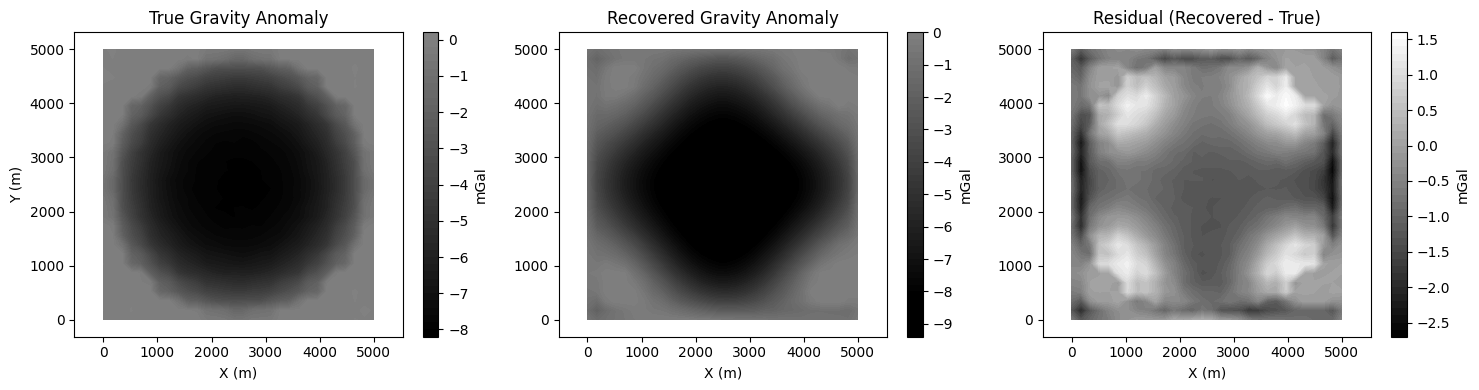

In [ ]:
# --- Reuse the inverted density model ---
# (Already constructed in the previous step as rho_inverted)

# --- Compute recovered gravity anomaly ---
rho_contrast_inverted = rho_inverted - 3500.0
gz_recovered = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast_inverted)
gz_residual = gz_recovered - gz  # Difference between inverted and true (with noise)
vmax = np.max(np.abs(gz))  # For consistent color scale

plt.figure(figsize=(15, 4))

# --- True anomaly ---
plt.subplot(1, 3, 1)
cont1 = plt.contourf(Xobs[:, 0], Yobs[0, :], gz.T, 50, cmap='', vmin=-vmax, vmax=vmax)
plt.colorbar(cont1, label='mGal')
plt.title('True Gravity Anomaly')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')

# --- Recovered anomaly ---
plt.subplot(1, 3, 2)
cont2 = plt.contourf(Xobs[:, 0], Yobs[0, :], gz_recovered.T, 50, cmap='', vmin=-vmax, vmax=vmax)
plt.colorbar(cont2, label='mGal')
plt.title('Recovered Gravity Anomaly')
plt.xlabel('X (m)')
plt.axis('equal')

# --- Residual (Difference) ---
plt.subplot(1, 3, 3)
cont3 = plt.contourf(Xobs[:, 0], Yobs[0, :], gz_residual.T, 50, cmap='')
plt.colorbar(cont3, label='mGal')
plt.title('Residual (Recovered - True)')
plt.xlabel('X (m)')
plt.axis('equal')

plt.tight_layout()
plt.show()


Iteration 01: Misfit = 40.3866
Iteration 02: Misfit = 40.3866
Iteration 03: Misfit = 35.2548
Iteration 04: Misfit = 35.2548
Iteration 05: Misfit = 35.1332
Iteration 06: Misfit = 35.1332
Iteration 07: Misfit = 34.2732
Iteration 08: Misfit = 27.9237
Iteration 09: Misfit = 26.4208
Iteration 10: Misfit = 24.2303
Iteration 11: Misfit = 22.9232
Iteration 12: Misfit = 22.9232
Iteration 13: Misfit = 22.9232
Iteration 14: Misfit = 22.9232
Iteration 15: Misfit = 22.9232
Iteration 16: Misfit = 22.9232
Iteration 17: Misfit = 22.9232
Iteration 18: Misfit = 22.9232
Iteration 19: Misfit = 20.2644
Iteration 20: Misfit = 20.2644
Iteration 21: Misfit = 20.2644
Iteration 22: Misfit = 19.6208
Iteration 23: Misfit = 16.8584
Iteration 24: Misfit = 16.8584
Iteration 25: Misfit = 16.7747
Iteration 26: Misfit = 16.7747
Iteration 27: Misfit = 16.7747
Iteration 28: Misfit = 16.7747
Iteration 29: Misfit = 16.7747
Iteration 30: Misfit = 16.2697

Inversion completed.
Recovered control point depths (m):
[[107.707137

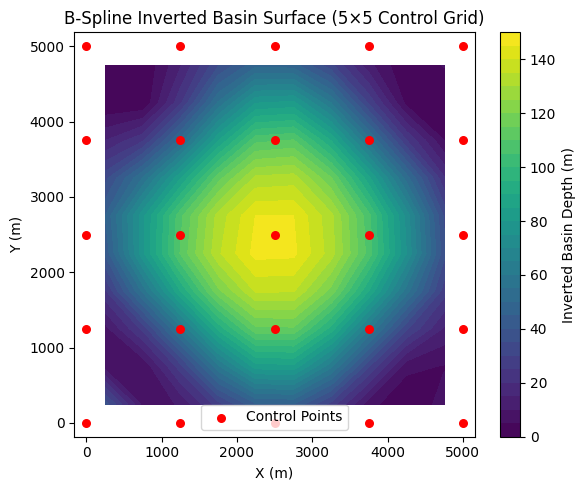

In [ ]:
from scipy.optimize import differential_evolution
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt

# --- Control Grid Parameters ---
n_ctrl_x, n_ctrl_y = 5, 5
x_ctrl = np.linspace(0, Lx, n_ctrl_x)
y_ctrl = np.linspace(0, Ly, n_ctrl_y)

# --- Interpolation Function using B-Spline ---
def interpolate_basin_spline(control_depths):
    depth_grid = control_depths.reshape((n_ctrl_x, n_ctrl_y))
    spline = RectBivariateSpline(x_ctrl, y_ctrl, depth_grid, kx=3, ky=3)  # Bicubic
    basin_surface = spline(xc, yc)  # shape (nx, ny)
    return np.clip(basin_surface, 0, max_depth)

# --- Objective (Misfit) Function ---
def misfit_spline(control_depths):
    basin_depth = interpolate_basin_spline(control_depths)

    # Build full 3D density model
    rho_model = np.full((nx, ny, nz), 3500.0)
    for k, z in enumerate(zc):
        rho_z = rho_top + (rho_bot - rho_top) * (z / max_depth)
        mask = z < basin_depth
        rho_model[:, :, k][mask] = rho_z

    rho_contrast = rho_model - 3500.0
    gz_pred = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast)
    return np.linalg.norm(gz_pred - gz)

# --- Callback Function to Track Iterations ---
iteration = {'count': 0}
def callback_spline(xk, convergence):
    iteration['count'] += 1
    current_misfit = misfit_spline(xk)
    print(f"Iteration {iteration['count']:02d}: Misfit = {current_misfit:.4f}")

# --- Inversion Settings ---
num_params = n_ctrl_x * n_ctrl_y
bounds = [(0, max_depth)] * num_params

# --- Run Differential Evolution Inversion ---
result_spline = differential_evolution(
    misfit_spline,
    bounds,
    strategy='randtobest1bin',
    maxiter=30,
    popsize=20,
    mutation=(0.5, 1.0),     
    recombination=0.9,
    callback=callback_spline,
    polish=True,
    disp=False
)


# --- Extract Best Parameters ---
best_depths = result_spline.x
depth_grid = best_depths.reshape((n_ctrl_x, n_ctrl_y))
print("\nInversion completed.\nRecovered control point depths (m):")
print(depth_grid)

# --- Plot Recovered Basin Surface ---
recovered_basin = interpolate_basin_spline(best_depths)

plt.figure(figsize=(6, 5))
plt.contourf(Xc2d, Yc2d, recovered_basin, 30, cmap='viridis')
plt.colorbar(label='Inverted Basin Depth (m)')
Xc_grid, Yc_grid = np.meshgrid(x_ctrl, y_ctrl, indexing='ij')
plt.scatter(Xc_grid.ravel(), Yc_grid.ravel(), c='red', s=30, label='Control Points')
plt.title('B-Spline Inverted Basin Surface (5×5 Control Grid)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


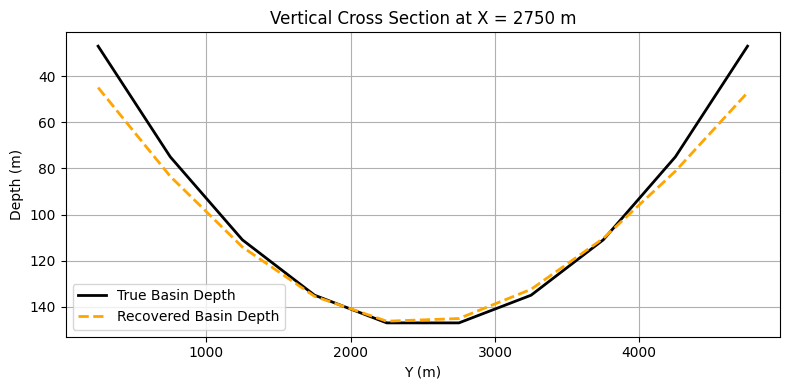

In [14]:
# --- Plot vertical cross-section through Y-direction at center X ---
ix = nx // 2  # Midpoint along X
y_vals = yc
true_section = basin_depth[ix, :]  # True surface depth
recovered_section = recovered_basin[ix, :]  # Inverted surface depth

plt.figure(figsize=(8, 4))
plt.plot(y_vals, true_section, label='True Basin Depth', color='black', linewidth=2)
plt.plot(y_vals, recovered_section, label='Recovered Basin Depth', color='orange', linewidth=2, linestyle='--')

plt.gca().invert_yaxis()
plt.xlabel("Y (m)")
plt.ylabel("Depth (m)")
plt.title(f'Vertical Cross Section at X = {xc[ix]:.0f} m')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Iteration 1: Misfit = 65.4095
Iteration 2: Misfit = 65.4095
Iteration 3: Misfit = 50.5989
Iteration 4: Misfit = 50.5989
Iteration 5: Misfit = 50.5989
Iteration 6: Misfit = 50.5989
Iteration 7: Misfit = 50.5989
Iteration 8: Misfit = 50.5989
Iteration 9: Misfit = 50.5989
Iteration 10: Misfit = 50.5989
Iteration 11: Misfit = 50.5989
Iteration 12: Misfit = 50.5989
Iteration 13: Misfit = 50.5989
Iteration 14: Misfit = 49.1491
Iteration 15: Misfit = 49.1491
Iteration 16: Misfit = 49.1491
Iteration 17: Misfit = 49.1491
Iteration 18: Misfit = 43.3167
Iteration 19: Misfit = 43.3167
Iteration 20: Misfit = 43.3167
Iteration 21: Misfit = 43.3167
Iteration 22: Misfit = 43.3167
Iteration 23: Misfit = 42.6949
Iteration 24: Misfit = 42.6949
Iteration 25: Misfit = 35.0567
Iteration 26: Misfit = 35.0567
Iteration 27: Misfit = 35.0567
Iteration 28: Misfit = 32.5798
Iteration 29: Misfit = 32.3164
Iteration 30: Misfit = 32.3164
Iteration 31: Misfit = 32.3164
Iteration 32: Misfit = 31.0778
Iteration 33: Mis

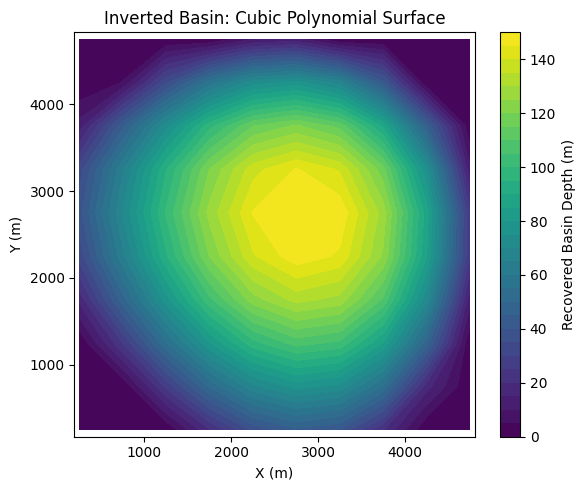

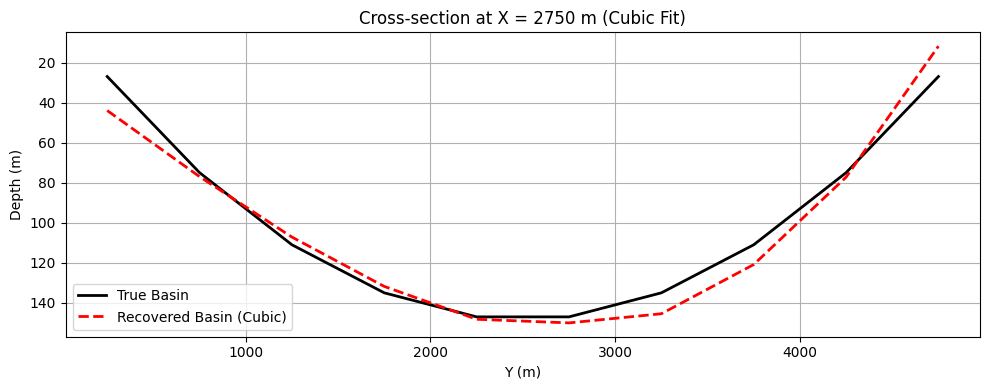

In [ ]:
# --- Cubic Polynomial Basin Inversion ---
from scipy.optimize import differential_evolution

# --- Objective Function (Cubic Polynomial) ---
def cubic_poly_misfit(params):
    # Unpack 10 coefficients
    a0, a1, a2, a3, a4, a5, a6, a7, a8, a9 = params

    # Compute basin depth
    X = Xc2d
    Y = Yc2d
    Z = (
        a0 + a1*X + a2*Y + a3*X**2 + a4*Y**2 + a5*X*Y +
        a6*X**3 + a7*Y**3 + a8*X**2*Y + a9*X*Y**2
    )

    # Clip to physical range
    basin_depth = np.clip(Z, 0, max_depth)

    # Build 3D density model
    rho_model_test = np.full((nx, ny, nz), 3500.0)
    for k, z in enumerate(zc):
        rho_z = rho_top + (rho_bot - rho_top) * (z / max_depth)
        mask = z < basin_depth
        rho_model_test[:, :, k][mask] = rho_z

    # Compute gravity
    rho_contrast_test = rho_model_test - 3500.0
    gz_pred = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast_test)

    return np.linalg.norm(gz_pred - gz)

# --- Callback to track progress ---
iteration_cubic = {'count': 0}
def callback_cubic(xk, convergence):
    iteration_cubic['count'] += 1
    current_misfit = cubic_poly_misfit(xk)
    print(f"Iteration {iteration_cubic['count']}: Misfit = {current_misfit:.4f}")

# Replace cubic bounds with more generous ones
cubic_bounds = [(-300, 300),     # a0
                (-5e-2, 5e-2),   # a1
                (-5e-2, 5e-2),   # a2
                (-1e-5, 1e-5),   # a3
                (-1e-5, 1e-5),   # a4
                (-1e-5, 1e-5),   # a5
                (-1e-8, 1e-8),   # a6
                (-1e-8, 1e-8),   # a7
                (-1e-8, 1e-8),   # a8
                (-1e-8, 1e-8)]   # a9


# --- Run DE Inversion ---
result_cubic = differential_evolution(
    cubic_poly_misfit,
    bounds=cubic_bounds,
    strategy='best1bin',
    maxiter=100,
    popsize=12,
    polish=True,
    disp=False,
    callback=callback_cubic
)

# --- Extract and Plot Recovered Basin ---
params = result_cubic.x
X = Xc2d
Y = Yc2d
Zfit_cubic = (
    params[0] + params[1]*X + params[2]*Y + params[3]*X**2 + params[4]*Y**2 +
    params[5]*X*Y + params[6]*X**3 + params[7]*Y**3 + params[8]*X**2*Y + params[9]*X*Y**2
)
Zfit_cubic = np.clip(Zfit_cubic, 0, max_depth)

# Plot full 2D surface
plt.figure(figsize=(6, 5))
plt.contourf(Xc2d, Yc2d, Zfit_cubic, 30, cmap='viridis')
plt.colorbar(label='Recovered Basin Depth (m)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Inverted Basin: Cubic Polynomial Surface')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Cross-section comparison
ix = nx // 2
xline = xc[ix]
true_slice = basin_depth[ix, :]
recovered_slice = Zfit_cubic[ix, :]

plt.figure(figsize=(10, 4))
plt.plot(yc, true_slice, 'k-', label='True Basin', linewidth=2)
plt.plot(yc, recovered_slice, 'r--', label='Recovered Basin (Cubic)', linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Y (m)")
plt.ylabel("Depth (m)")
plt.title(f'Cross-section at X = {xline:.0f} m (Cubic Fit)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# from scipy.optimize import differential_evolution

# # --- Objective Function for DE ---
# def misfit(params):
#     h0, x0, y0, sigma = params

#     # Create Gaussian basin depth model
#     R2 = (Xc2d - x0)**2 + (Yc2d - y0)**2
#     basin_depth = h0 * np.exp(-R2 / (2 * sigma**2))

#     # Clip to max_depth
#     basin_depth[basin_depth > max_depth] = max_depth
#     basin_depth[basin_depth < 0] = 0.0

#     # Build density model with vertical gradient
#     rho_model_test = np.full((nx, ny, nz), 3500.0)
#     for k, z in enumerate(zc):
#         rho_z = rho_top + (rho_bot - rho_top) * (z / max_depth)
#         mask = z < basin_depth
#         rho_model_test[:, :, k][mask] = rho_z

#     # Compute density contrast
#     rho_contrast_test = rho_model_test - 3500.0

#     # Forward model
#     gz_pred = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast_test)

#     # Misfit = L2 norm
#     return np.linalg.norm(gz_pred - gz)

# # --- Parameter bounds: [h0, x0, y0, sigma] ---
# bounds = [
#     (10, 200),       # h0 (depth)
#     (0, Lx),         # x0
#     (0, Ly),         # y0
#     (200, 5000)      # sigma
# ]


# # --- Track DE progress ---
# iteration = {'count': 0}

# def iteration_callback(xk, convergence):
#     iteration['count'] += 1
#     h0, x0, y0, sigma = xk
#     current_misfit = misfit(xk)
#     print(f"Iteration {iteration['count']}: Misfit = {current_misfit:.4f} | h0 = {h0:.2f}, x0 = {x0:.1f}, y0 = {y0:.1f}, sigma = {sigma:.1f}")

# # --- Run DE Inversion ---
# result = differential_evolution(
#     misfit,
#     bounds,
#     strategy='best1bin',
#     maxiter=100,
#     popsize=15,
#     polish=True,
#     disp=False,  # we'll handle custom printing via callback
#     callback=iteration_callback
# )


# best_params = result.x
# print(f"\nRecovered Parameters:\n h0 = {best_params[0]:.2f} m\n x0 = {best_params[1]:.2f} m\n y0 = {best_params[2]:.2f} m\n sigma = {best_params[3]:.2f} m")

# # --- Plot Recovered Basin ---
# h0, x0, y0, sigma = best_params
# R2 = (Xc2d - x0)**2 + (Yc2d - y0)**2
# recovered_depth = h0 * np.exp(-R2 / (2 * sigma**2))
# recovered_depth[recovered_depth > max_depth] = max_depth

# plt.figure(figsize=(6, 5))
# plt.contourf(Xc2d, Yc2d, recovered_depth, 30, cmap='viridis')
# plt.colorbar(label='Recovered Basin Depth (m)')
# plt.xlabel('X (m)')
# plt.ylabel('Y (m)')
# plt.title('Inverted Gaussian Basin Shape')
# plt.axis('equal')
# plt.tight_layout()
# plt.show()


In [ ]:
from scipy.optimize import differential_evolution

iteration_log = {"count": 0}

def build_density_model(basin_depth_flat):
    basin_depth = np.array(basin_depth_flat).reshape((nx, ny))
    rho_model = np.full((nx, ny, nz), 3500.0)
    for k, z in enumerate(zc):
        rho_z = rho_top + (rho_bot - rho_top) * (z / max_depth)
        mask = z < basin_depth
        rho_model[:, :, k][mask] = rho_z
    return rho_model

def misfit(basin_depth_flat):
    basin_depth = np.array(basin_depth_flat).reshape((nx, ny))
    rho_model_trial = build_density_model(basin_depth)
    rho_contrast_trial = rho_model_trial - 3500.0
    gz_pred = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast_trial)

    data_misfit=np.sqrt(np.mean((gz_pred - gz)**2))

    # Regularization: Smoothness penalty (2nd-order differences)
    reg = 0.0
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            d2x = basin_depth[i+1,j] - 2*basin_depth[i,j] + basin_depth[i-1,j]
            d2y = basin_depth[i,j+1] - 2*basin_depth[i,j] + basin_depth[i,j-1]
            reg += d2x**2 + d2y**2
    reg *= 1e-2  # λ: regularization weight

    return data_misfit + reg

# --- Callback function for logging ---
def iteration_callback(xk, convergence):
    iteration_log["count"] += 1
    current_misfit = misfit(xk)
    print(f"Iteration {iteration_log['count']}: Misfit = {current_misfit:.4f}")

# --- Run DE inversion with callback ---
bounds = [(0, max_depth) for _ in range(nx * ny)]
result = differential_evolution(
    misfit,
    bounds,
    strategy='best1bin',
    maxiter=35,
    popsize=10,
    tol=1e-6,init='sobol',
    callback=iteration_callback,
    disp=True,
    polish=False
)

# --- Extract best-fit basin depth ---
basin_depth_est = result.x.reshape((nx, ny))


differential_evolution step 1: f(x)= 904.0396979234574
Iteration 1: Misfit = 904.0397
differential_evolution step 2: f(x)= 843.1249049089687
Iteration 2: Misfit = 843.1249
differential_evolution step 3: f(x)= 843.1249049089687
Iteration 3: Misfit = 843.1249
differential_evolution step 4: f(x)= 568.9148598804884
Iteration 4: Misfit = 568.9149
differential_evolution step 5: f(x)= 547.0947357277577
Iteration 5: Misfit = 547.0947
differential_evolution step 6: f(x)= 540.7100839447562
Iteration 6: Misfit = 540.7101
differential_evolution step 7: f(x)= 540.7100839447562
Iteration 7: Misfit = 540.7101
differential_evolution step 8: f(x)= 534.3684209683498
Iteration 8: Misfit = 534.3684
differential_evolution step 9: f(x)= 394.5396094514639
Iteration 9: Misfit = 394.5396
differential_evolution step 10: f(x)= 394.5396094514639
Iteration 10: Misfit = 394.5396
differential_evolution step 11: f(x)= 394.5396094514639
Iteration 11: Misfit = 394.5396
differential_evolution step 12: f(x)= 374.70955302

In [ ]:
from scipy.optimize import differential_evolution

# --- Log iteration count
iteration_log = {"count": 0}

# --- Build density model from flat basin depth vector
def build_density_model(basin_depth_flat):
    basin_depth = np.array(basin_depth_flat).reshape((nx, ny))
    rho_model = np.full((nx, ny, nz), 3500.0)

    # For each depth slice, assign density if inside the basin
    for k, z in enumerate(zc):
        rho_z = rho_top + (rho_bot - rho_top) * (z / max_depth)
        for i in range(nx):
            for j in range(ny):
                if z < basin_depth[i, j]:
                    rho_model[i, j, k] = rho_z
    return rho_model

# --- Misfit function with RMSE and regularization
def misfit(basin_depth_flat):
    basin_depth = np.array(basin_depth_flat).reshape((nx, ny))
    rho_model_trial = build_density_model(basin_depth)
    rho_contrast_trial = rho_model_trial - 3500.0
    gz_pred = compute_gravity(Xobs, Yobs, Zobs, x_edges, y_edges, z_edges, rho_contrast_trial)

    # RMSE data misfit
    data_misfit = np.sqrt(np.mean((gz_pred - gz)**2))

    # Regularization: Smoothness (second differences)
    reg = 0.0
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            d2x = basin_depth[i+1, j] - 2 * basin_depth[i, j] + basin_depth[i-1, j]
            d2y = basin_depth[i, j+1] - 2 * basin_depth[i, j] + basin_depth[i, j-1]
            reg += d2x**2 + d2y**2
    λ = 1e-2  # regularization weight (adjust if needed)
    total_misfit = data_misfit + λ * reg

    return total_misfit

# --- Iteration callback to monitor progress
def iteration_callback(xk, convergence):
    iteration_log["count"] += 1
    current_misfit = misfit(xk)
    print(f"Iteration {iteration_log['count']}: Misfit = {current_misfit:.4f}")

# --- Define bounds for each parameter (0 to max_depth)
bounds = [(0, max_depth) for _ in range(nx * ny)]

result = differential_evolution(
    misfit, bounds,
    strategy='best1bin',
    maxiter=50,
    popsize=10,
    mutation=(0.7, 1.5),   # Encourage more varied solutions
    recombination=0.9,
    init='sobol',
    callback=iteration_callback,
    disp=True,
    polish=False
)


# --- Extract final inverted basin depth
basin_depth_est = result.x.reshape((nx, ny))


differential_evolution step 1: f(x)= 805.9401449708826
Iteration 1: Misfit = 805.9401
differential_evolution step 2: f(x)= 454.5233361005978
Iteration 2: Misfit = 454.5233
differential_evolution step 3: f(x)= 454.5233361005978
Iteration 3: Misfit = 454.5233
differential_evolution step 4: f(x)= 454.5233361005978
Iteration 4: Misfit = 454.5233
differential_evolution step 5: f(x)= 454.5233361005978
Iteration 5: Misfit = 454.5233
differential_evolution step 6: f(x)= 454.5233361005978
Iteration 6: Misfit = 454.5233
differential_evolution step 7: f(x)= 454.5233361005978
Iteration 7: Misfit = 454.5233
differential_evolution step 8: f(x)= 454.5233361005978
Iteration 8: Misfit = 454.5233
differential_evolution step 9: f(x)= 454.5233361005978
Iteration 9: Misfit = 454.5233
differential_evolution step 10: f(x)= 454.5233361005978
Iteration 10: Misfit = 454.5233
differential_evolution step 11: f(x)= 454.5233361005978
Iteration 11: Misfit = 454.5233
differential_evolution step 12: f(x)= 454.52333610